# Running Moondream on a Mac Studio

Moondream just shipped [Photon 1.2.0](https://moondream.ai/blog/photon-1-2-0-update), their inference runtime — the headline is **native Apple Silicon support via Metal kernels** (no CUDA, no Triton). Their flagship is **Moondream 3 Preview** (9 B params total, 2 B active via MoE-style routing) and it advertises caption / query / detect / point as primitives.

I run on a 64 GB M2 Max Mac Studio, so this should be a clean fit. Let's see what actually works.

## What I tried first (and why it didn't work)

The marketing path is one line:

```bash
pip install moondream
```

```python
import moondream as md
model = md.vl(local=True)        # → loads the Photon engine on MPS
```

Engine init crashes with a native-code symbol mismatch. The compiled `_kestrel_mps.so` ships looking for two C++ symbols that, between them, **don't co-exist in any public PyTorch wheel**:

| torch | `at::mps::MPSStream::device()` (added ~2.7) | `c10::TensorImpl::decref_pyobject()` (removed ~2.6) | result |
|---|---|---|---|
| 2.5.1 | ❌ | ✓ | dlopen fails |
| 2.6.0 | ❌ | ✓ | dlopen fails |
| 2.7.0 | ✓ | ❌ | dlopen fails |
| 2.7.1 | ✓ | ❌ | dlopen fails |
| 2.8.0 | ✓ | ❌ | dlopen fails |
| 2.9.1 | ✓ | ❌ | dlopen fails |

The kestrel-kernels wheel was built against a torch ABI that isn't shipped on PyPI — likely an internal nightly. Until they cut a refreshed wheel, **`local=True` is unusable from a regular pip install on Apple Silicon**.

## What works today

The previous-generation **`vikhyatk/moondream2`** (1.93 B params) loads cleanly from Hugging Face via `transformers`, runs on MPS, and exposes the same `caption / query / detect / point` API. That's what we'll use for the demos. The model is small enough to load in ~12 s and run several inferences per second on the M2 Max.

In [1]:
import time
from pathlib import Path
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image

MODEL_ID = 'vikhyatk/moondream2'
REVISION = '2025-04-14'           # pin the model revision so this notebook reproduces
DEVICE   = 'mps' if torch.backends.mps.is_available() else 'cpu'

t0 = time.time()
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, trust_remote_code=True, revision=REVISION).to(DEVICE)
tok   = AutoTokenizer.from_pretrained(MODEL_ID, revision=REVISION)
n_params = sum(p.numel() for p in model.parameters())
print(f'loaded {MODEL_ID}@{REVISION} in {time.time()-t0:.1f}s '
      f'· {n_params/1e9:.2f} B params · device={DEVICE}')

/private/tmp/moondream_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded vikhyatk/moondream2@2025-04-14 in 4.3s · 1.93 B params · device=mps


## Helpers

Tiny wrappers so the cells below stay focused on what each capability actually does.

In [2]:
from PIL import ImageDraw, ImageFont
import io
from IPython.display import display

IMG_DIR = Path('images')

def load(name):
    return Image.open(IMG_DIR / name).convert('RGB')

def time_call(fn, *a, **k):
    t = time.time()
    out = fn(*a, **k)
    return out, time.time() - t

def show(img, max_w=560):
    if img.width > max_w:
        h = int(img.height * max_w / img.width)
        img = img.resize((max_w, h))
    display(img)

def draw_boxes(img, det, label='', color='red'):
    out = img.copy(); d = ImageDraw.Draw(out); W, H = out.size
    for o in det.get('objects', []):
        box = (o['x_min']*W, o['y_min']*H, o['x_max']*W, o['y_max']*H)
        d.rectangle(box, outline=color, width=4)
        if label:
            d.text((box[0]+4, box[1]+2), label, fill=color)
    return out

def draw_points(img, pts, label='', color='lime', r=8):
    out = img.copy(); d = ImageDraw.Draw(out); W, H = out.size
    for p in pts.get('points', []):
        x, y = p['x']*W, p['y']*H
        d.ellipse((x-r, y-r, x+r, y+r), outline=color, width=3)
        if label:
            d.text((x+r+2, y-r), label, fill=color)
    return out

## Caption — "what is this image?"

Free-form image description. Three different photos.

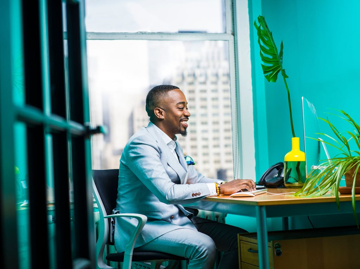

[desk_worker.jpg] 5.65s
  The image shows a man seated at a wooden desk in a modern office. He is dressed in a light blue suit and is smiling as he works on a laptop. The desk is positioned in front of a large window, offering a view of a cityscape. The office features a teal or turquoise wall, a black office chair, and a yellow vase with a green plant. A telephone is also visible on the desk. The man is wearing a light blue or grey wristwatch.



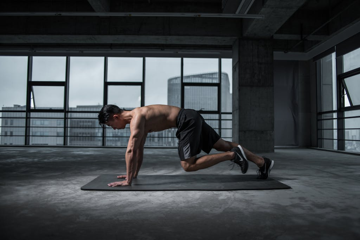

[person4.jpg] 4.34s
  A man is performing a push-up exercise on a black exercise mat in a spacious, industrial-style gym. He is shirtless and wearing black shorts and athletic shoes. The gym features a concrete floor and large windows that offer a view of a city skyline. The man's body is in a plank position, with his hands firmly grasping the mat, demonstrating the strength and balance required for this exercise.



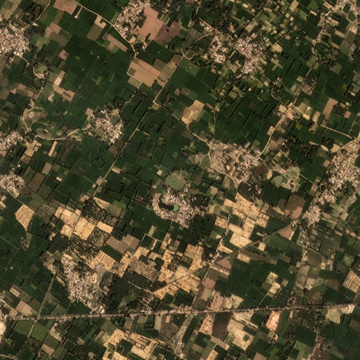

[kiln_tile.jpg] 6.56s
  The image presents an aerial view of a rural landscape, likely captured from a satellite or drone. The terrain is a patchwork of green fields, interspersed with patches of brown and tan, suggesting a mix of agricultural land and possibly some areas of dry or less fertile land. The fields are arranged in a roughly rectangular pattern, with some areas showing signs of human activity, such as roads or paths. The image also reveals a network of roads and paths crisscrossing the landscape, connecting the various agricultural areas. The colors in the image are predominantly green, brown, and tan, with some areas of darker green, possibly indicating dense vegetation or different types of crops. The image does not contain any discernible text or human-made objects, and the relative positions of the fields and roads remain consistent throughout the image.



In [3]:
for name in ['desk_worker.jpg', 'person4.jpg', 'kiln_tile.jpg']:
    img = load(name)
    show(img, 360)
    cap, dt = time_call(model.caption, img)
    print(f'[{name}] {dt:.2f}s')
    print(' ', cap['caption'].strip())
    print()

## Query — "answer a specific question about this image"

Same image, different questions. This is the closest thing to chat-with-an-image and is where Moondream tends to feel snappiest.

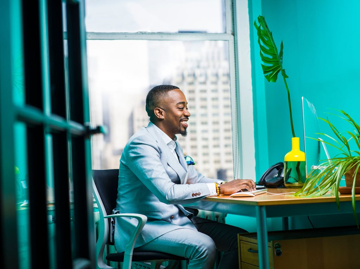

Q: What colour is the man's jacket?
A: The man's jacket is light blue.    (2.11s)



Q: Is he wearing a wristwatch? If yes, on which arm?
A: Yes, the man is wearing a wristwatch on his left wrist.    (2.35s)



Q: How many plants are visible?
A: There are two plants visible in the image.    (2.11s)



Q: What appears outside the window?
A: Outside the window, there are tall buildings visible, suggesting that the man is in an urban setting.    (2.39s)



In [4]:
img = load('desk_worker.jpg')
show(img, 360)
questions = [
    "What colour is the man's jacket?",
    "Is he wearing a wristwatch? If yes, on which arm?",
    "How many plants are visible?",
    "What appears outside the window?",
]
for q in questions:
    ans, dt = time_call(model.query, img, q)
    print(f'Q: {q}\nA: {ans["answer"].strip()}    ({dt:.2f}s)\n')

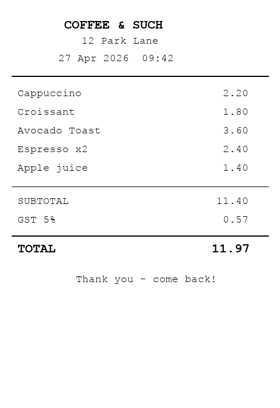

Q: What is the printed total?
A: 11.97    (1.74s)



Q: List all items and their prices.
A: Cappuccino: 2.20
Croissant: 1.80
Avocado Toast: 3.60
Espresso x2: 2.40
Apple juice: 1.40
SUBTOTAL: 11.40
GST: 0.57
TOTAL: 11.97    (3.65s)



Q: What is the GST percentage?
A: 5%    (1.41s)



In [5]:
# A more demanding image: the synthetic receipt from the ReAct post.
img = load('receipt.png')
show(img, 280)
for q in [
    "What is the printed total?",
    "List all items and their prices.",
    "What is the GST percentage?",
]:
    ans, dt = time_call(model.query, img, q)
    print(f'Q: {q}\nA: {ans["answer"].strip()}    ({dt:.2f}s)\n')

## Detect — open-vocabulary object boxes

No fixed class list: you describe what you want, you get back boxes in normalised `(x_min, y_min, x_max, y_max)` coords.

detect[person]  1 hit(s)  1.96s


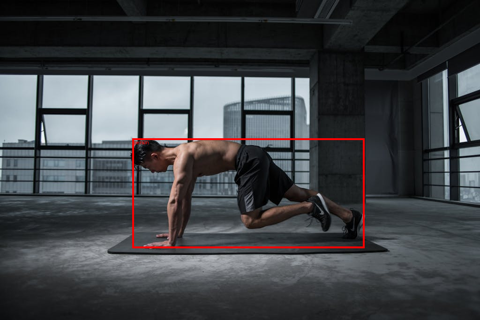

detect[sneaker]  2 hit(s)  2.42s


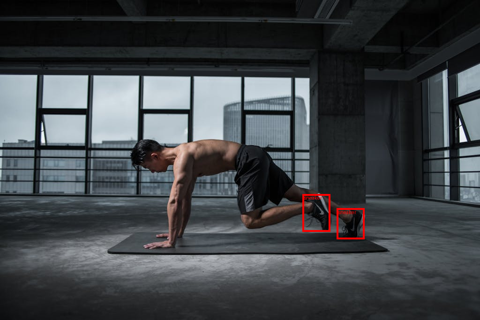

detect[window]  6 hit(s)  2.24s


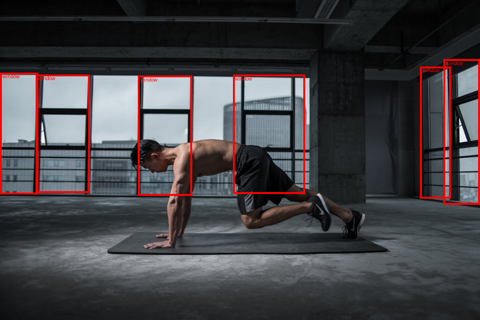

In [6]:
img = load('person4.jpg')
for prompt in ['person', 'sneaker', 'window']:
    det, dt = time_call(model.detect, img, prompt)
    n = len(det.get('objects', []))
    print(f'detect[{prompt}]  {n} hit(s)  {dt:.2f}s')
    show(draw_boxes(img, det, label=prompt, color='red'), 480)

## Point — "where is X?"

Returns a list of `(x, y)` centres in normalised coordinates. Cheaper than detect (no box regression) and useful for click-targets, for cropping further inspection, or as a feature for downstream layout reasoning.

point[keyboard]  1 hit(s)  1.80s


point[plant]  1 hit(s)  1.81s


point[chair]  1 hit(s)  1.82s


point[wristwatch]  1 hit(s)  1.94s


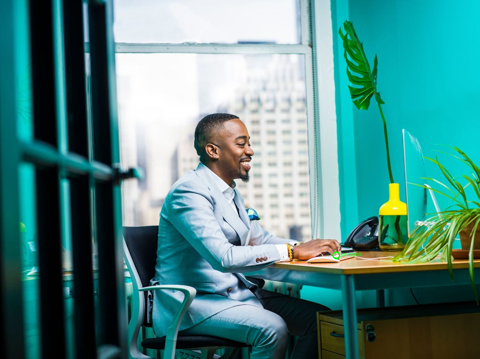

In [7]:
img = load('desk_worker.jpg')
for prompt in ['keyboard', 'plant', 'chair', 'wristwatch']:
    pts, dt = time_call(model.point, img, prompt)
    n = len(pts.get('points', []))
    print(f'point[{prompt}]  {n} hit(s)  {dt:.2f}s')
show(draw_points(img, model.point(img, 'keyboard'), label='keyboard'), 480)

## Stress test — counting (the famous VLM weak spot)

Same `dots.png` we used in the [ReAct post](../2026-04-27-react-local/react.ipynb): 23 red + 14 blue = 37 total. Both Gemma 4 31B and Sapiens-2 stumble on this. How does Moondream do?

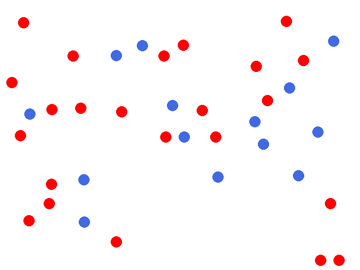

Q: How many dots are in this image?
A: 25   (1.42s)


Q: How many red dots?
A: 15   (1.80s)


Q: How many blue dots?
A: 10   (1.39s)



point[red dot] -> 20 hits (2.59s)


point[blue dot] -> 14 hits (2.14s)


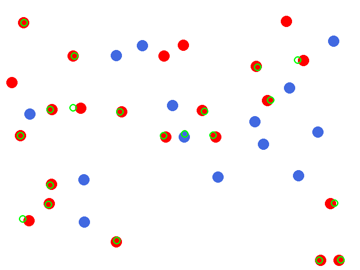

In [8]:
img = load('dots.png')
show(img, 360)
for q in [
    "How many dots are in this image?",
    "How many red dots?",
    "How many blue dots?",
]:
    ans, dt = time_call(model.query, img, q)
    print(f'Q: {q}\nA: {ans["answer"].strip()}   ({dt:.2f}s)')
print()
# Also try the explicit point() endpoint, which can give a better count.
for prompt in ['red dot', 'blue dot']:
    pts, dt = time_call(model.point, img, prompt)
    print(f'point[{prompt}] -> {len(pts["points"])} hits ({dt:.2f}s)')
show(draw_points(img, model.point(img, 'red dot'), color='lime'), 360)

## Stress test — out-of-distribution (Sentinel-2 satellite tile)

A 640×640 tile from the [SentinelKilnDB](https://github.com/rishabh-mondal/SENTINELKILNDB_NeurIPS_2025) Lucknow set — agricultural land with a few brick kilns clustered in the lower-right. Moondream wasn't trained on overhead imagery, so this is a deliberate OOD probe.

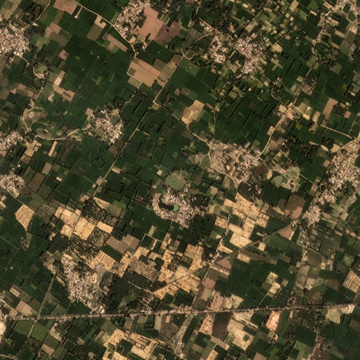

Q: Describe this image.
A: The image presents an aerial view of a rural landscape, showcasing a vast expanse of green fields and patches of brown and tan. The fields are scattered across the landscape, with some areas showing a mix of green and brown hues. The terrain appears relatively flat, with no visible hills or mountains in the distance.

Numerous small buildings and structures are scattered throughout the landscape, adding a human touch to the otherwise natural scene. These buildings are dispersed across the fields, with some located near the edges of the image and others in the middle. The image captures the beauty of rural life, with the open fields and scattered buildings creating a picturesque scene.   (5.35s)



Q: What kind of land is shown?
A: The image shows a large area of farmland, which is a mix of green fields and patches of brown.   (2.05s)



Q: Are there any brick kilns visible?
A: Yes, there are brick kilns visible in the image, located in the middle of the field.   (2.16s)



Q: How many distinct settlements or villages can you see?
A: There are several distinct settlements or villages visible in the image, scattered across the green fields and farmland.   (2.17s)



In [9]:
img = load('kiln_tile.jpg')
show(img, 360)
for q in [
    "Describe this image.",
    "What kind of land is shown?",
    "Are there any brick kilns visible?",
    "How many distinct settlements or villages can you see?",
]:
    ans, dt = time_call(model.query, img, q)
    print(f'Q: {q}\nA: {ans["answer"].strip()}   ({dt:.2f}s)\n')

## Takeaways

- **Photon 1.2.0 binary is broken** on Apple Silicon as of this writing — the kestrel-kernels wheel was compiled against a torch ABI that isn't shipped to PyPI. Tracking issue worth filing upstream; for now, `local=True` doesn't load.
- **Moondream 2 (1.93 B) via `transformers` works fine on MPS** — 12 s cold start, ~2-5 s per query depending on the question. Captions are fluent; query/detect/point all return structured outputs.
- **Strengths**: free-form Q&A on RGB photos, open-vocabulary detection, fast `point` endpoint. The grounded primitives (detect, point) are the differentiator vs general-purpose VLMs — they're cheaper than asking an LLM to type out coordinates.
- **Weaknesses**: counting (the dots stress test undercounts in the same way every VLM does), and overhead/satellite imagery — which is fair, the training data is consumer photos.
- **What I'd reach for tomorrow**: `point` to seed crops for a heavier downstream model. Cheap localisation is undervalued.

If/when the Photon 1.2.0 binary lands a fixed wheel, the upgrade should be drop-in (Moondream 3's `caption / query / detect / point` API is unchanged from 2). Until then, this notebook is the working version.